# Analisis exploratorio de los datos preprocesados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np

## I. Cargar datos

In [4]:
file_path = 'data/interim/data_limpios.csv'
df=pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year == 2024]
df = df[df['date'].dt.month == 7]
df = df[df['Zona'] == "CENTRO"]
df = df.set_index('date')
df.head()

,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,Zona
date,,,,,,,,,,,,,,,,
2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,CENTRO
2024-07-01 01:00:00,0.41,1.8,5.8,7.9,14.0,27.0,6.52,714.6,0.0,87.0,2.3,0.0,21.56,7.5,35.0,CENTRO
2024-07-01 02:00:00,0.42,2.5,6.3,9.0,13.0,26.0,NaN,714.2,0.0,88.0,2.4,0.0,21.44,5.8,32.0,CENTRO
2024-07-01 03:00:00,0.37,3.8,8.0,12.1,10.0,31.0,NaN,713.5,0.0,88.0,2.4,0.0,21.37,6.0,16.0,CENTRO
2024-07-01 04:00:00,0.42,4.5,12.8,17.5,6.0,33.0,NaN,713.3,0.0,87.0,2.4,0.0,21.46,5.2,354.0,CENTRO


In [41]:
df.shape

(744, 16)

Diccionario de Variables (Basado en data_limpios.csv): Es vital clasificar las variables por su naturaleza física y estadística. Basado en tu archivo, sugiero esta estructura:

Variable Temporal: date (Debe ser convertida a objeto datetime). Es el índice de tu serie de tiempo.

Variables Categóricas (Nominales): Zona (ej. CENTRO, NORTE). Esta es crucial para segmentar el análisis espacial.

Variables Numéricas (Continuas) - Contaminantes: CO, NO, NO2, NOX, O3, PM10, PM2.5, SO2.

Variables Numéricas (Continuas) - Meteorológicas:

PRS (Presión): Importante para la estabilidad atmosférica.

RAINF (Lluvia): Generalmente tiene muchos ceros (distribución inflada en ceros).

RH (Humedad Relativa): Afecta la formación de aerosoles secundarios.

SR (Radiación Solar): Motor de reacciones fotoquímicas (Ozono).

TOUT (Temperatura): Correlacionada con O3.

WSR (Velocidad del Viento) y WDR (Dirección del Viento): Claves para la dispersión.

Primero se identificarán los datos nulos con el objetivo de facilitar la elección del método de imputación de datos. 

## II. Medidas Estadísticas (Variables Cuantitativas)

In [50]:
cols_numericas = df.select_dtypes(include=[np.number]).columns
estadisticos = df[cols_numericas].describe().T
estadisticos

,count,mean,std,min,25%,50%,75%,max
CO,742.0,0.562547,0.170248,0.14,0.450,0.5400,0.63000,1.590
NO,724.0,5.427072,5.097005,1.80,2.100,3.0000,7.02500,30.300
NO2,742.0,12.091240,6.309701,3.20,7.100,10.7500,15.50000,50.500
NOX,742.0,17.670620,10.197040,5.20,9.800,14.0000,23.30000,63.500
O3,739.0,24.937754,18.259390,4.00,10.000,20.0000,34.00000,103.000
PM10,740.0,59.027027,19.316867,19.00,44.000,56.0000,72.00000,136.000
PM2.5,635.0,23.969953,10.866110,3.02,15.000,22.0400,31.44500,55.000
PRS,742.0,711.714016,1.568858,707.40,710.700,711.5500,712.80000,715.500
RAINF,742.0,0.002453,0.028368,0.00,0.000,0.0000,0.00000,0.650
RH,742.0,64.867925,13.789191,27.00,55.000,66.0000,77.00000,92.000


In [43]:
estadisticos['mediana'] = df[cols_numericas].median()
estadisticos['sesgo'] = df[cols_numericas].skew()

estadisticos['mediana']

CO         0.5400
NO         3.0000
NO2       10.7500
NOX       14.0000
O3        20.0000
PM10      56.0000
PM2.5     22.0400
PRS      711.5500
RAINF      0.0000
RH        66.0000
SO2        2.6000
SR         0.0375
TOUT      26.1900
WSR        7.9000
WDR       67.0000
Name: mediana, dtype: float64

## III. Visualización y Distribución
*Histogramas (Análisis de Distribución):
*Boxplots (Diagramas de Caja):
*Mapa de Calor (Correlación de Pearson/Spearman):

## IV. Calidad de los datos

### Deteccion de nulos

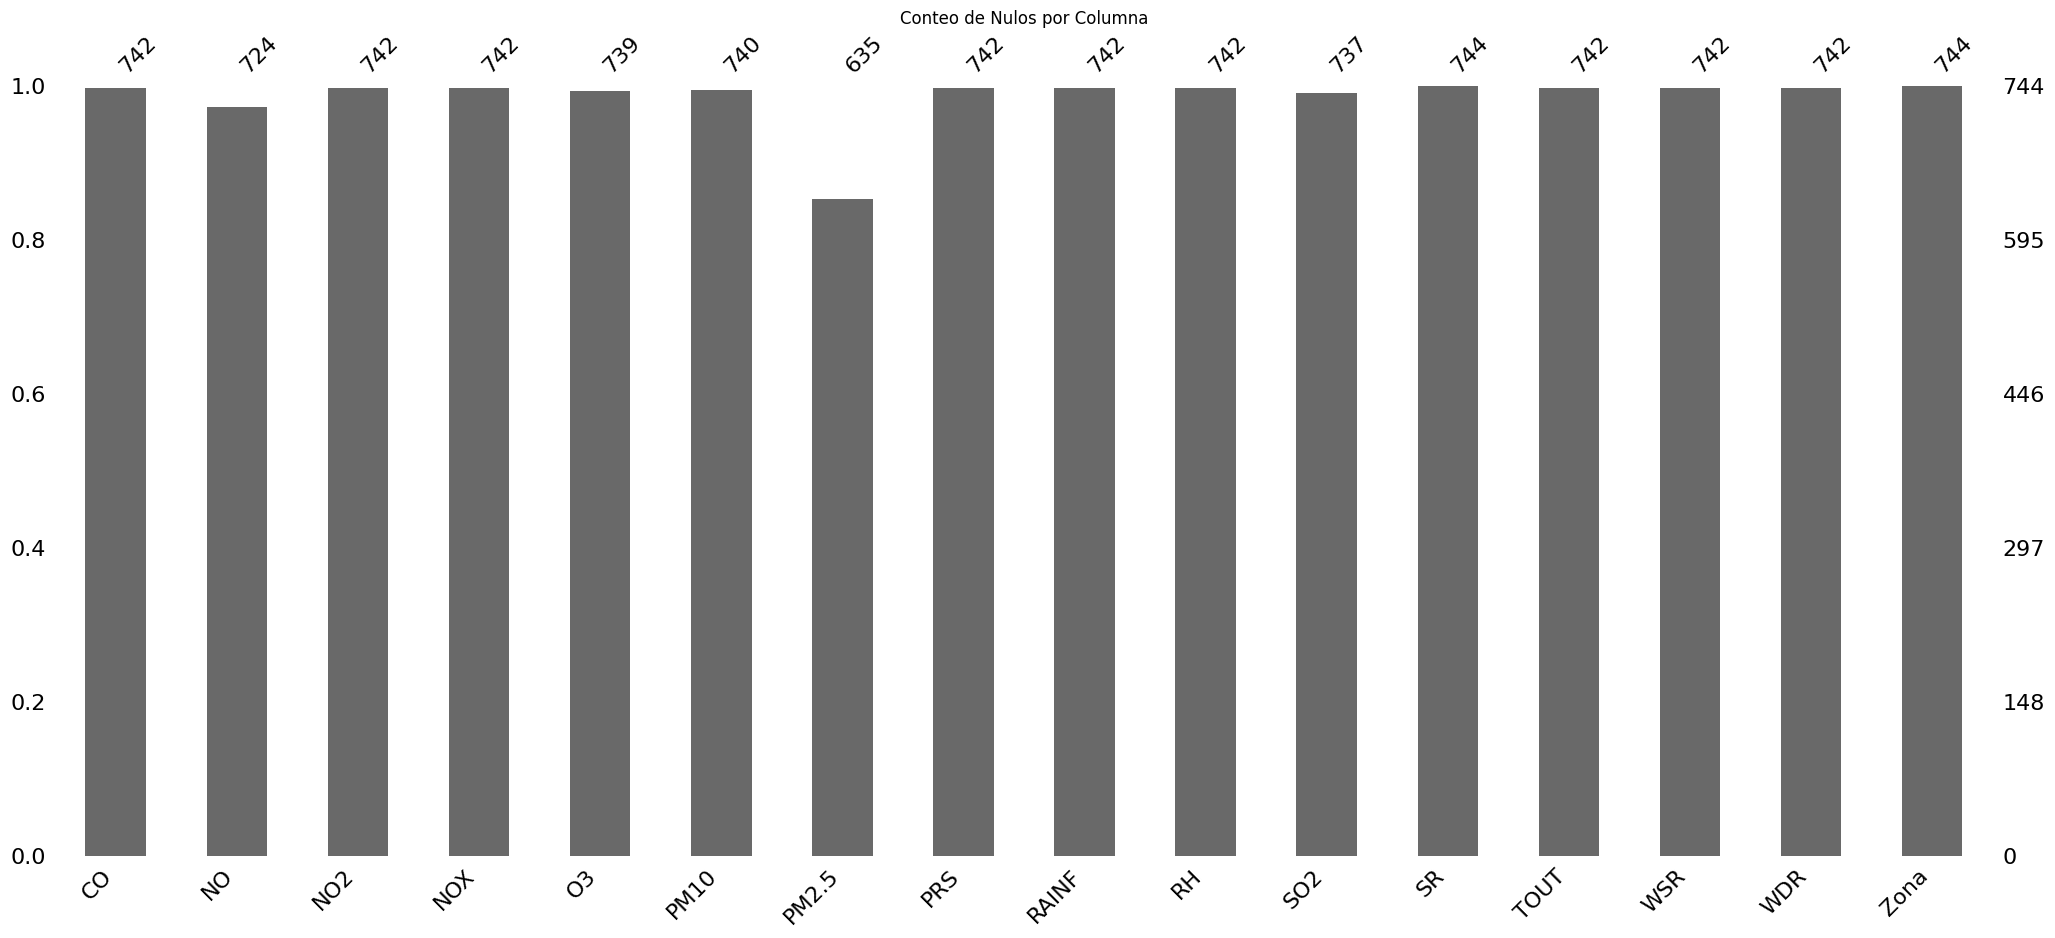

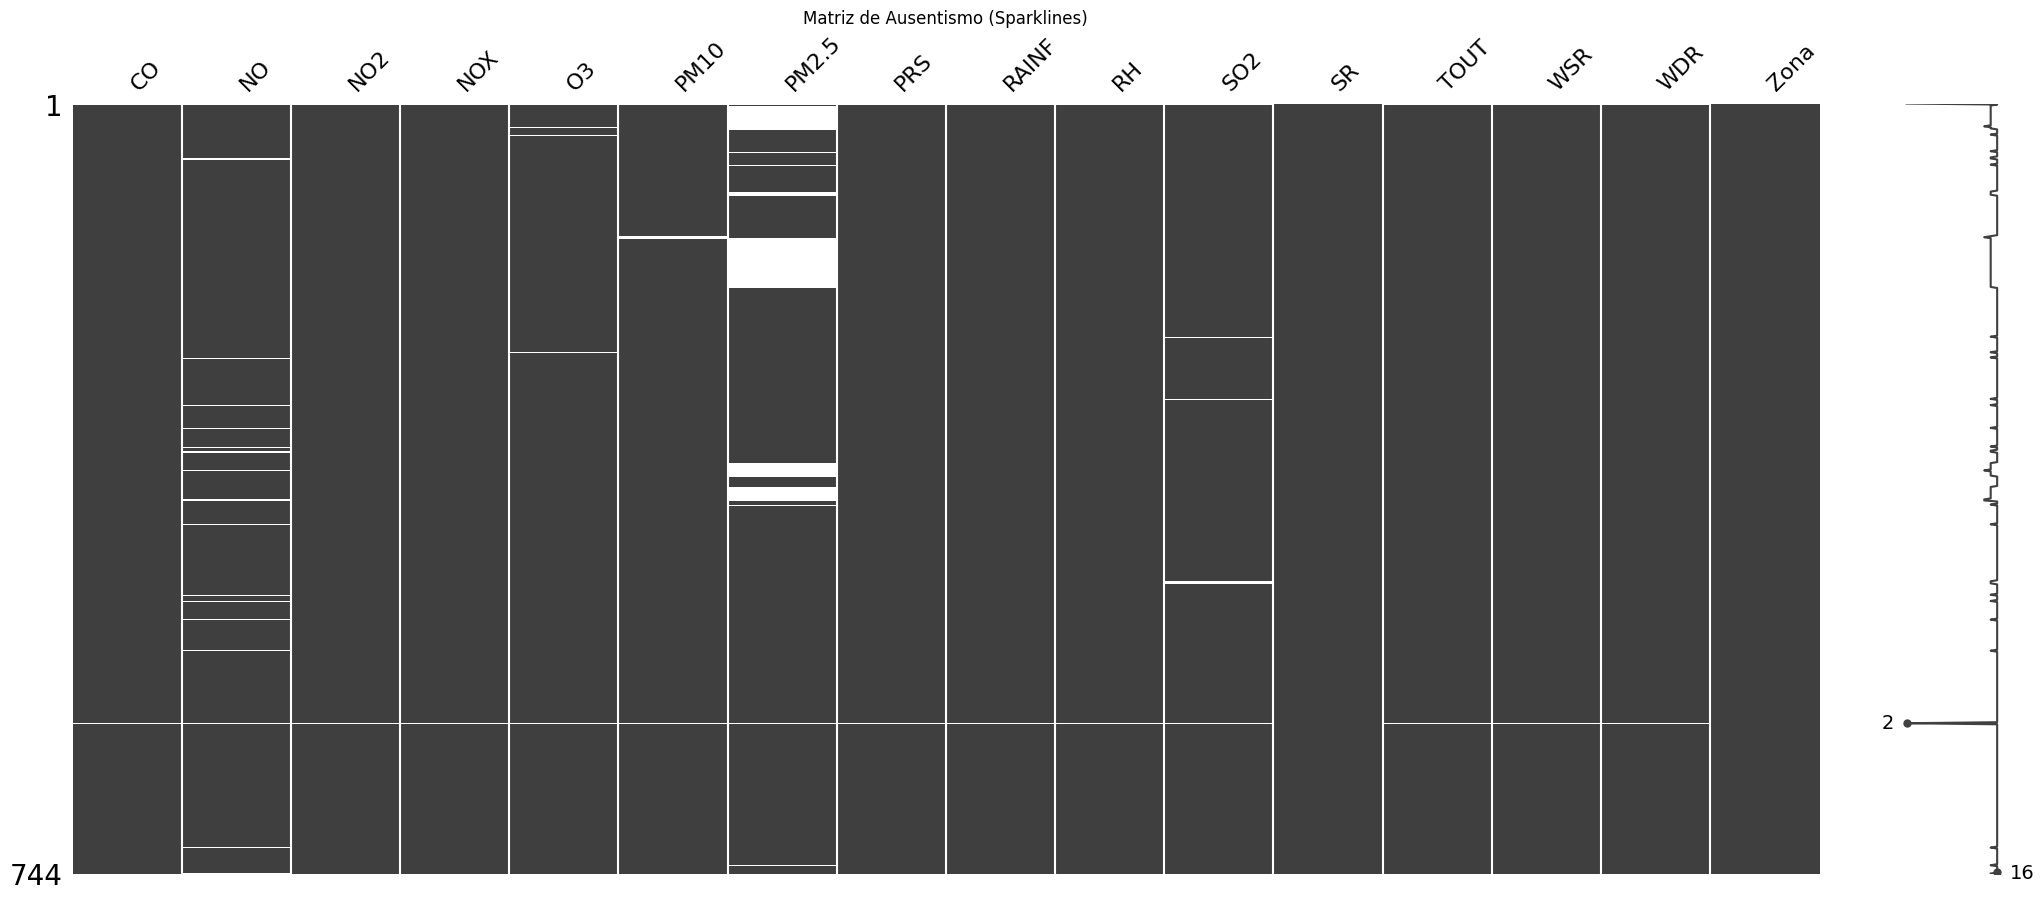

In [51]:
msno.bar(df)
plt.title('Conteo de Nulos por Columna')
plt.show()
msno.matrix(df)
plt.title('Matriz de Ausentismo (Sparklines)')
plt.show()

In [52]:
df.isnull().sum()

CO         2
NO        20
NO2        2
NOX        2
O3         5
PM10       4
PM2.5    109
PRS        2
RAINF      2
RH         2
SO2        7
SR         0
TOUT       2
WSR        2
WDR        2
Zona       0
dtype: int64

## V. Imputacion